## **Hindmarsh–Rose Network Model Learned by SREINet**

## **I. Setup and Preprocessing**

In [1]:
# Environment setup
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../../utilities'))

import tensorflow as tf
import numpy as np
from SREINet import *
import DataGenerator as DG

print('**********************************************')
print('*    Tensorflow Version: ' + tf.__version__ + '              *')
print('**********************************************')

from packaging import version
if version.parse(tf.__version__) < version.parse('2.10.0') or version.parse(tf.__version__) > version.parse('2.15.0'):
    raise SystemExit('Please use TensorFlow between 2.10.0 and 2.15.0')

MY_DATA_TYPE = 'float32'
tf.keras.backend.set_floatx(MY_DATA_TYPE)

from pruning_scheduler import PruningScheduler
from sreinet_trainer import SREINetTrainer

from loss import myLoss


**********************************************
*    Tensorflow Version: 2.15.0              *
**********************************************


### **1.2 Training Data**

#### Create dataset

Generated ER network with 25 nodes and 66 edges


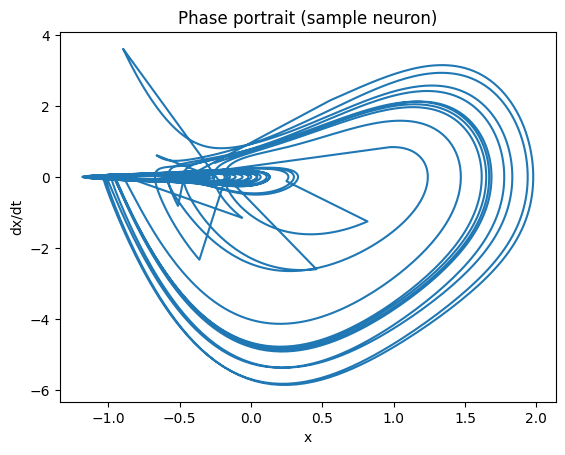

Training input shape: (80000, 75)
Training output shape: (80000, 75)


In [2]:
from hindmarsh_rose_network.hindmarsh_rose_model import hindmarsh_rose_network
from hindmarsh_rose_network.network_generator import generate_erdos_renyi_network

MY_DATA_TYPE = 'float32'
tf.keras.backend.set_floatx(MY_DATA_TYPE)

n_nodes = 25
edge_probability = 0.2
seed = 42

edge_list, adjacency, degrees = generate_erdos_renyi_network(n_nodes, edge_probability, seed=seed)

print(f'Generated ER network with {n_nodes} nodes and {edge_list.shape[0]} edges')

np.random.seed(seed)
num_traj = 10
initial_conditions = []
for _ in range(num_traj):
    x0 = np.random.uniform(-1.0, 1.0, size=n_nodes)
    y0 = np.random.uniform(-5.0, 0.0, size=n_nodes)
    z0 = np.random.uniform(1.0, 2.0, size=n_nodes)
    initial_state = np.concatenate([x0, y0, z0])
    initial_conditions.append(initial_state)

data_T = 80.0
data_dt = 0.01
myDG = DG.DataGenerator(initial_conditions, T=data_T, dt=data_dt, derivative_mode='exact')

def hr_vector_field(t, state, edge_list):
    return hindmarsh_rose_network(t, state, edge_list, coupling_strength=0.05, I=3.2)

T_arr, x_train, dx_train = myDG.generate_dataset_by_custom_ODEs(hr_vector_field, edge_list, method='RK45')

import matplotlib.pyplot as plt
plt.plot(x_train[:, 0], dx_train[:, 0])
plt.title('Phase portrait (sample neuron)')
plt.xlabel('x')
plt.ylabel('dx/dt')
plt.show()

training_input, training_output = x_train, dx_train
training_input_for_sim = training_input.copy()

print('Training input shape:', training_input.shape)
print('Training output shape:', training_output.shape)

MY_MODEL = 'Hindmarsh-Rose network (ER)'
data_initial_conditions = initial_conditions
guess_highest_order_polynomial = 3
ode_function = hr_vector_field
network_arguments = (edge_list,)


### **1.3 Hyperparameters**

In [3]:
MINI_BATCH_SIZE = 32
learning_rate = 0.001

### **1.4 Model Architecture Definitions**

**SREINet Parameters**

In [4]:
dim = training_input.shape[1]
layer_depth = guess_highest_order_polynomial
layer_neuron_nums_per_act_fn = [dim] * layer_depth
print(layer_neuron_nums_per_act_fn)


[75, 75, 75]


## **II. Model and Training Preparation**

### **2.1 Create the SREINet Model**

In [5]:
my_activation = [lambda x: x]
inputs = tf.keras.layers.Input(shape=(dim,), dtype=MY_DATA_TYPE)
model = SREINet(layer_neuron_nums_per_act_fn,
                 activations=my_activation,
                 weight_initializer=tf.initializers.random_normal(stddev=1e-5, seed=42),
                 data_type=MY_DATA_TYPE,
                 name='SREINet')
output = model(inputs)
model = tf.keras.Model(inputs=inputs, outputs=output)


### **2.2 Loss Function**

In [6]:
LOSS_FUNCTION = 'mse'  # Options: 'mse', 'lasso', 'ridge', 'elasticnet'
loss_fn = myLoss(model, LOSS_FUNCTION)


### **2.3 Optimizer**

In [7]:
my_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

### **2.4 Trainer**

In [8]:
np.set_printoptions(threshold=np.inf)
trainer = SREINetTrainer(model, my_optimizer, loss_fn, data_type=MY_DATA_TYPE)


## **III.Training the Model**

#### **Pruning Profile**

In [ ]:
MAX_WEIGHT_PRUNING_THRESHOLD = 0.10
N_PERIODS = 50
PRUNING_EPOCHS_PER_PERIOD = 40
NUM_EPOCHS = PRUNING_EPOCHS_PER_PERIOD * N_PERIODS
EARLY_STOPPING_LOSS_THRESHOLD = 1e-10
EARLY_STOPPING_PRUNING_THRESHOLD = 0.01

pruning_scheduler = PruningScheduler(
    steps_per_period=PRUNING_EPOCHS_PER_PERIOD,
    num_periods=N_PERIODS,
    maximum_threshold=MAX_WEIGHT_PRUNING_THRESHOLD,
    zero_percentage=0.2,
    ramp_percentage=0.75,
    ramp_type='sine',
    show_plot=False,
)


In [10]:
callbacks = []
training_histories = []
weights_list = []
for i in range(training_output.shape[1]):
    print(f'Training dimension {i + 1}...')
    trainer.reset_trainer_and_model_weights(i)
    output = training_output[:, i:i+1]
    history = trainer.fit(
        training_input,
        output,
        batch_size=MINI_BATCH_SIZE,
        validation_split=0.2,
        epochs=NUM_EPOCHS,
        pruning_scheduler=pruning_scheduler,
        callbacks=callbacks,
        early_stopping_loss_threshold=EARLY_STOPPING_LOSS_THRESHOLD,
        early_stopping_pruning_threshold=EARLY_STOPPING_PRUNING_THRESHOLD,
        shuffle_per_epoch=False,
        patience_periods=15,
        verbose=1,
    )
    training_histories.append(history)
    weights_list.append([trainer.get_best_weights()])


Training dimension 1...
Epoch   1 (Period 1):  Train Loss: 2.264e+00,  Validation Loss: 3.652e-02,  Epoch Time: 1.73s,  Current Pruning Threshold: 0
Epoch   2 (Period 1):  Train Loss: 2.298e-02,  Validation Loss: 1.747e-02,  Epoch Time: 1.50s,  Current Pruning Threshold: 0
Epoch   3 (Period 1):  Train Loss: 1.627e-02,  Validation Loss: 2.207e-02,  Epoch Time: 1.47s,  Current Pruning Threshold: 0
Epoch   4 (Period 1):  Train Loss: 1.955e-02,  Validation Loss: 1.999e-02,  Epoch Time: 1.48s,  Current Pruning Threshold: 0
Epoch   5 (Period 1):  Train Loss: 2.201e+01,  Validation Loss: 9.395e-01,  Epoch Time: 1.47s,  Current Pruning Threshold: 0
Epoch   6 (Period 1):  Train Loss: 1.142e-01,  Validation Loss: 2.632e-02,  Epoch Time: 1.47s,  Current Pruning Threshold: 0
Epoch   7 (Period 1):  Train Loss: 1.888e-02,  Validation Loss: 1.021e-02,  Epoch Time: 1.47s,  Current Pruning Threshold: 0
Epoch   8 (Period 1):  Train Loss: 9.341e-03,  Validation Loss: 9.379e-03,  Epoch Time: 1.49s,  Curre

KeyboardInterrupt: 

## **IV. Coefficient Reconstructor (SREINet)**

In [ ]:
# Define reconstruction helpers as needed


## **V. Results**

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(training_histories[0]['loss'])
plt.title('Training loss (dimension 1)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()
